# Classification of handwritten digits using various neural network models with PyTorch
* Multinomial classification task of images of handwritten digits (10 classes).
* The database has a training set of 60k examples, and a test set of 10k examples, each image is of 28x28 pixels size.
* The MNIST ("Modified National Institute of Standards and Technology") is the “hello world” dataset for computer vision. Since its release in 1999, this classic dataset of handwritten images has served as the basis for benchmarking classification algorithms.

## Model setup

Before we start we need to load libraries and setup the model parameters

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Current device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)

import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 14})

model_args = {}
# random seed
model_args['seed'] = 123
# we will use batch size of 128 in Stochastic Gradient Descent (SGD) optimization of the network
model_args['batch_size'] = 128
# learning rate is how fast it will descend
model_args['lr'] = .05
# SGD momentum (default: .5) momentum is a moving average of gradients (it helps to keep direction)
model_args['momentum'] = .5
# the number of epochs is the number of times you go through the full dataset
model_args['epochs'] = 50
# logging frequency
model_args['log_interval'] = 100

Torch version: 2.8.0
CUDA available: True
Current device: AMD Radeon RX 6600 XT


Let's start with loading the dataset and check how it looks like

In [2]:
# load the MINST dataset via torchvision
transform = transforms.Compose([transforms.ToTensor(),
                              transforms.Normalize((0.1307,), (0.3081,))])
mnist_train = datasets.MNIST('../data', train=True, download=True, transform=transform)
# we divide this data into training and validation subsets
train_subset, validation_subset = torch.utils.data.random_split(mnist_train, [50000, 10000])
test_subset = datasets.MNIST('../data', train=False, download=True, transform=transform)

In [3]:
# define dataloaders
loader_kwargs = {'batch_size': model_args['batch_size'],
                 'num_workers': 2,
                 'pin_memory': True,
                 'shuffle': True}
train_loader = torch.utils.data.DataLoader(train_subset, **loader_kwargs)
validation_loader = torch.utils.data.DataLoader(validation_subset, **loader_kwargs)
test_loader = torch.utils.data.DataLoader(test_subset, **loader_kwargs)

Plot sample images

50000
10000
10000
391
torch.Size([28, 28])


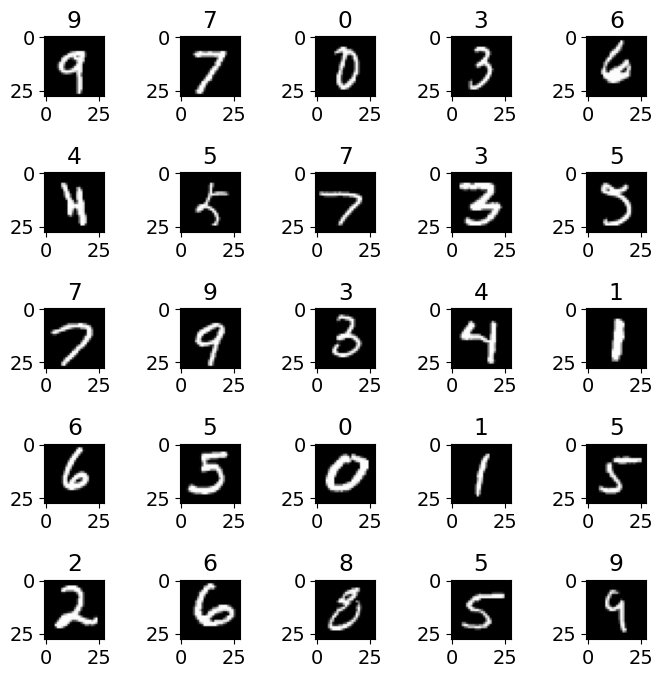

In [4]:
print(len(train_subset))
print(len(validation_subset))
print(len(test_subset)) # we have data already divided into train & validation & test subsets
print(len(train_loader)) # no of train batches
example_number = 123
print(train_subset[example_number][0][0].shape) # single item shape

fig, axs = plt.subplots(5, 5, figsize=(7,7), tight_layout=True)
for i in range(5):
    for j in range(5):
        axs[i,j].imshow(train_subset[example_number+i*5+j][0].reshape(28,28), cmap='gray')
        axs[i,j].set_title(train_subset[example_number+i*5+j][1])

Let's now construct the NN model:
- then test **deep** network with some (fully-connected) *hidden* layers,

In [5]:
class Deep(nn.Module):
    # this defines the structure of the Perceptron model
    def __init__(self):
        super(Deep, self).__init__()
        # fully connected layers
        self.fc1 = nn.Linear(28*28, 20)
        self.fc2 = nn.Linear(20, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.fc1(x)
        x = F.relu(x)
        # hidden layer
        x = self.fc2(x)
        return F.log_softmax(x, dim=1) # note that dim=0 is the number of samples in batch

And define training, testing, and plotting utils:

In [6]:
def train(model, device, train_loader, optimizer, epoch_number):
    model.train()
    train_loss = 0.
    # get subsequent batches over the data in a given epoch
    for batch_idx, (data, target) in enumerate(train_loader):
        # send data tensors to GPU (or CPU)
        data, target = data.to(device), target.to(device)
        # this will zero out the gradients for this batch
        optimizer.zero_grad()
        # this will execute the forward() function
        output = model(data)
        # calculate the negative-log-likelihood loss
        loss = F.nll_loss(output, target, reduction='mean')
        # backpropagate the loss
        loss.backward()
        # update the model weights (with assumed learning rate)
        optimizer.step()
        if batch_idx % model_args['log_interval'] == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch_number, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))
        train_loss += loss.item()
    train_loss /= len(train_loader)
    print('\nTrain set: Average loss: {:.4f}'.format(train_loss))
    return train_loss

def test(model, device, test_loader, message):
    model.eval()
    test_loss = 0.
    correct = 0
    # this is just inference, we don't need to calculate gradients
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            # calculate and sum up batch loss
            test_loss += F.nll_loss(output, target, reduction='mean')
            # get the index of class with the max log-probability
            prediction = output.argmax(dim=1)
            # item() returns value of the given tensor
            correct += prediction.eq(target).sum().item()
    test_loss /= len(test_loader)
    print('{}: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        message, test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))
    return test_loss.cpu()

def plot_loss(train_loss, validation_loss, title):
    plt.grid(True)
    plt.xlabel("subsequent epochs")
    plt.ylabel('average loss')
    plt.plot(range(1, len(train_loss)+1), train_loss, 'o-', label='training')
    plt.plot(range(1, len(validation_loss)+1), validation_loss, 'o-', label='validation')
    plt.legend()
    plt.title(title)
    plt.show()

## Experiments

2. Add a hidden layer to the *Perceptron* and evaluate the *Deep* model

Train Epoch: 1 [0/50000 (0%)]	Loss: 2.361859
Train Epoch: 1 [12800/50000 (26%)]	Loss: 0.349760
Train Epoch: 1 [25600/50000 (51%)]	Loss: 0.303016
Train Epoch: 1 [38400/50000 (77%)]	Loss: 0.325077

Train set: Average loss: 0.4104
Validation set: Average loss: 0.2757, Accuracy: 9175/10000 (92%)

Train Epoch: 2 [0/50000 (0%)]	Loss: 0.266673
Train Epoch: 2 [12800/50000 (26%)]	Loss: 0.206007
Train Epoch: 2 [25600/50000 (51%)]	Loss: 0.195300
Train Epoch: 2 [38400/50000 (77%)]	Loss: 0.242311

Train set: Average loss: 0.2362
Validation set: Average loss: 0.2293, Accuracy: 9305/10000 (93%)

Train Epoch: 3 [0/50000 (0%)]	Loss: 0.286749
Train Epoch: 3 [12800/50000 (26%)]	Loss: 0.306199
Train Epoch: 3 [25600/50000 (51%)]	Loss: 0.333736
Train Epoch: 3 [38400/50000 (77%)]	Loss: 0.248425

Train set: Average loss: 0.1972
Validation set: Average loss: 0.2087, Accuracy: 9372/10000 (94%)

Train Epoch: 4 [0/50000 (0%)]	Loss: 0.258082
Train Epoch: 4 [12800/50000 (26%)]	Loss: 0.136912
Train Epoch: 4 [25600/5

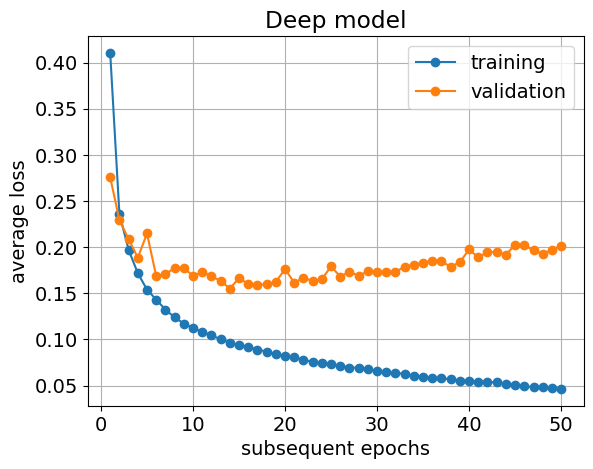

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Deep().to(device)

optimizer = optim.SGD(model.parameters(),
                      lr=model_args['lr'],
                      momentum=model_args['momentum'])
                      #weight_decay=1.e-3)
#optimizer = optim.Adadelta(model.parameters(), lr=model_args['lr'])

torch.manual_seed(model_args['seed'])
train_loss = []
validation_loss = []
for epoch_number in range(1, model_args['epochs'] + 1):
    train_loss.append(train(model, device, train_loader, optimizer, epoch_number))
    validation_loss.append(test(model, device, validation_loader, 'Validation set'))

test(model, device, test_loader, 'Test set')
plot_loss(train_loss, validation_loss, 'Deep model')

**Change 1: Add weight_decay = 1.e-3 in optimizer**
- It adds aditional penalty for big weights (pulling weights to zero)

Train Epoch: 1 [0/50000 (0%)]	Loss: 2.360940
Train Epoch: 1 [12800/50000 (26%)]	Loss: 0.345771
Train Epoch: 1 [25600/50000 (51%)]	Loss: 0.311833
Train Epoch: 1 [38400/50000 (77%)]	Loss: 0.334453

Train set: Average loss: 0.4173
Validation set: Average loss: 0.2912, Accuracy: 9139/10000 (91%)

Train Epoch: 2 [0/50000 (0%)]	Loss: 0.262676
Train Epoch: 2 [12800/50000 (26%)]	Loss: 0.219241
Train Epoch: 2 [25600/50000 (51%)]	Loss: 0.212843
Train Epoch: 2 [38400/50000 (77%)]	Loss: 0.264173

Train set: Average loss: 0.2479
Validation set: Average loss: 0.2357, Accuracy: 9294/10000 (93%)

Train Epoch: 3 [0/50000 (0%)]	Loss: 0.330128
Train Epoch: 3 [12800/50000 (26%)]	Loss: 0.302926
Train Epoch: 3 [25600/50000 (51%)]	Loss: 0.331761
Train Epoch: 3 [38400/50000 (77%)]	Loss: 0.246190

Train set: Average loss: 0.2054
Validation set: Average loss: 0.2217, Accuracy: 9361/10000 (94%)

Train Epoch: 4 [0/50000 (0%)]	Loss: 0.250697
Train Epoch: 4 [12800/50000 (26%)]	Loss: 0.196808
Train Epoch: 4 [25600/5

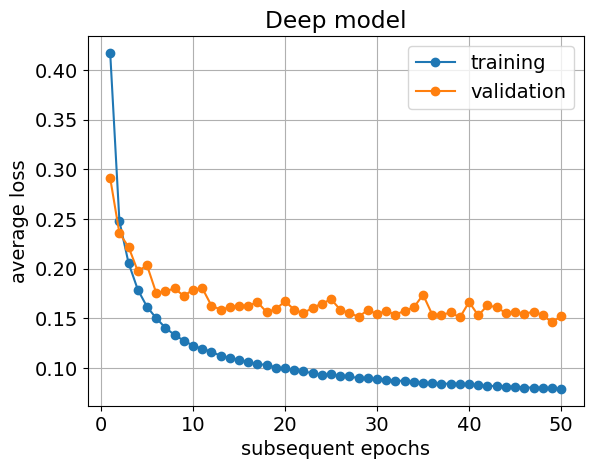

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Deep().to(device)

optimizer = optim.SGD(model.parameters(),
                      lr=model_args['lr'],
                      momentum=model_args['momentum'],
                      weight_decay=1.e-3)
#optimizer = optim.Adadelta(model.parameters(), lr=model_args['lr'])

torch.manual_seed(model_args['seed'])
train_loss = []
validation_loss = []
for epoch_number in range(1, model_args['epochs'] + 1):
    train_loss.append(train(model, device, train_loader, optimizer, epoch_number))
    validation_loss.append(test(model, device, validation_loader, 'Validation set'))

test(model, device, test_loader, 'Test set')
plot_loss(train_loss, validation_loss, 'Deep model')

**Change 2: Add additional dropout layer p=0.2 to the model**
- which is zeroing 20% of weights during the training


In [21]:
class Deep(nn.Module):
    # this defines the structure of the Perceptron model
    def __init__(self, p_dropout):
        super(Deep, self).__init__()
        # fully connected layers
        self.fc1 = nn.Linear(28*28, 20)
        self.fc2 = nn.Linear(20, 10)
        self.dropout = nn.Dropout(p=p_dropout)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        # hidden layer
        x = self.fc2(x)
        return F.log_softmax(x, dim=1) # note that dim=0 is the number of samples in batch

Train Epoch: 1 [0/50000 (0%)]	Loss: 2.374846
Train Epoch: 1 [12800/50000 (26%)]	Loss: 0.549129
Train Epoch: 1 [25600/50000 (51%)]	Loss: 0.437929
Train Epoch: 1 [38400/50000 (77%)]	Loss: 0.474136

Train set: Average loss: 0.5694
Validation set: Average loss: 0.3014, Accuracy: 9082/10000 (91%)

Train Epoch: 2 [0/50000 (0%)]	Loss: 0.431288
Train Epoch: 2 [12800/50000 (26%)]	Loss: 0.330726
Train Epoch: 2 [25600/50000 (51%)]	Loss: 0.343889
Train Epoch: 2 [38400/50000 (77%)]	Loss: 0.437724

Train set: Average loss: 0.3937
Validation set: Average loss: 0.2606, Accuracy: 9225/10000 (92%)

Train Epoch: 3 [0/50000 (0%)]	Loss: 0.439786
Train Epoch: 3 [12800/50000 (26%)]	Loss: 0.433136
Train Epoch: 3 [25600/50000 (51%)]	Loss: 0.447926
Train Epoch: 3 [38400/50000 (77%)]	Loss: 0.387934

Train set: Average loss: 0.3575
Validation set: Average loss: 0.2471, Accuracy: 9297/10000 (93%)

Train Epoch: 4 [0/50000 (0%)]	Loss: 0.381869
Train Epoch: 4 [12800/50000 (26%)]	Loss: 0.397076
Train Epoch: 4 [25600/5

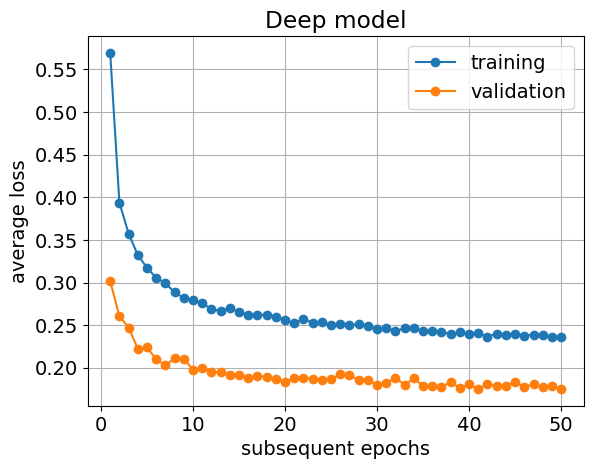

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Deep(p_dropout=0.2).to(device)

optimizer = optim.SGD(model.parameters(),
                      lr=model_args['lr'],
                      momentum=model_args['momentum'],
                      weight_decay=1.e-3)
#optimizer = optim.Adadelta(model.parameters(), lr=model_args['lr'])

torch.manual_seed(model_args['seed'])
train_loss = []
validation_loss = []
for epoch_number in range(1, model_args['epochs'] + 1):
    train_loss.append(train(model, device, train_loader, optimizer, epoch_number))
    validation_loss.append(test(model, device, validation_loader, 'Validation set'))

test(model, device, test_loader, 'Test set')
plot_loss(train_loss, validation_loss, 'Deep model')

## Summary
* *Deep* and *CNN* models with accuracies of 96% and 97% (evaluated on the test subset) perform much better than single-layer *Perceptron* with 92%;
* The two smallest (and simplest) models appear to be overfitted. To deal with this we need to apply some regularization.
* Validation subset is evaluated during the training (as opposed to test set, infered *after* the training) in order to tune the model hiperparameters (that describe e.g. the network structure, or training details).
* A moment to stop trainning is a kind of hipermarameter -- by applying *early stopping* we can avoid overfitting.



## Tasks to do
* apply some regularization technique to *Deep* model in order to avoid overfitting (start with nonzero *weight_decay* in optimizer)
* try to figure out why the validation loss for *CNN* model turns to be *lower* than the train loss (hint: turn off regularization),
* **tune one of these models to get the *Test Set Accuracy* > 99%**,
* plot the *confusion matrix* among all of the classes---which of digits are mostly confused with each other?
>How to build the confusion matrix?
> * for example 1st row represents images with "0" digit (*ground truth*), while 1st colum images for which the model *predicts* "0",
> * this way element _11 is equal to number of images with "0" corectly clasified as "0" (true positives), while _15 means number of images with "0" wrongly calssified as "4", and so on.